In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [204]:
episode_df = pd.read_csv(r"dataset\fineTuned\episodes\episode_unbalanced.csv",index_col=0)
embeddings = np.load(r"dataset\fineTuned\embeddings\unbalanced_episode_embeddings.npy")
episode_df['published_date'] = pd.to_datetime(episode_df['published_date'])
episode_df = episode_df.reset_index()

In [205]:
print("Number of sentences:", len(episode_df))
episode_df.head()

Number of sentences: 122


,orig_index,content_id,sentence,published_date,category,episode
0,5110,1282697,Holt became hostile when the customer tried to...,2024-02-13,Gadgets,45
1,5106,1282697,"Pierre Holt, 32, is accused of using a pen cam...",2024-02-13,Gadgets,45
2,5105,1282697,A customer tried to leave a note for a store c...,2024-02-13,Gadgets,45
3,5073,1284526,The employee also found a second camera in the...,2024-02-15,Gadgets,45
4,5068,1284526,Investigators said at least 10 people were see...,2024-02-15,Gadgets,45


In [206]:
indices = episode_df["orig_index"].values
episode_embeddings = embeddings[indices]

In [207]:
start_time = episode_df['published_date'].min()
end_time = episode_df['published_date'].max()

print("Start:", start_time)
print("End:", end_time)

duration = (end_time - start_time).days
print("Duration (days):", duration)

Start: 2024-02-13 00:00:00
End: 2024-12-18 00:00:00
Duration (days): 309


## Event Timeline

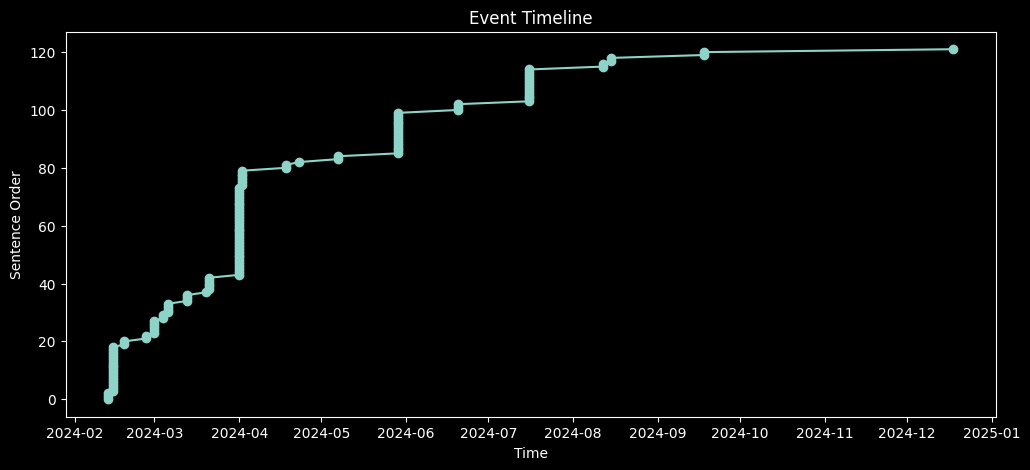

In [208]:
plt.figure(figsize=(12,5))

plt.plot(
    episode_df['published_date'],
    range(len(episode_df)),
    marker='o'
)

plt.title("Event Timeline")
plt.xlabel("Time")
plt.ylabel("Sentence Order")

plt.show()

## Event Clustering

In [209]:
import hdbscan

In [210]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,
    metric='euclidean'
)

event_labels = clusterer.fit_predict(episode_embeddings)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [211]:
episode_df["event_id"] = event_labels
episode_df.head()

,orig_index,content_id,sentence,published_date,category,episode,event_id
0,5110,1282697,Holt became hostile when the customer tried to...,2024-02-13,Gadgets,45,-1
1,5106,1282697,"Pierre Holt, 32, is accused of using a pen cam...",2024-02-13,Gadgets,45,-1
2,5105,1282697,A customer tried to leave a note for a store c...,2024-02-13,Gadgets,45,-1
3,5073,1284526,The employee also found a second camera in the...,2024-02-15,Gadgets,45,2
4,5068,1284526,Investigators said at least 10 people were see...,2024-02-15,Gadgets,45,-1


In [212]:
print("Number of events detected:", len(set(event_labels)) - (1 if -1 in event_labels else 0))
print(episode_df["event_id"].value_counts())

Number of events detected: 4
-1    69
 2    41
 0     5
 1     4
 3     3
Name: event_id, dtype: int64


In [213]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(episode_embeddings)

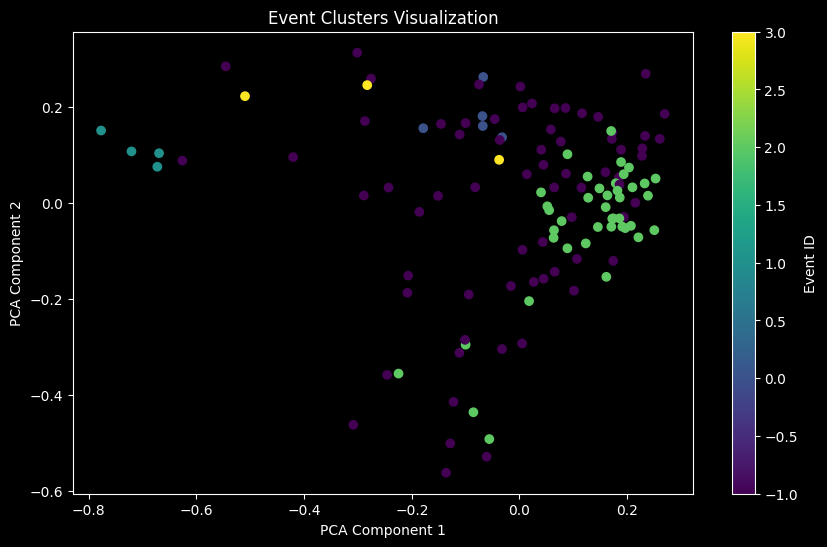

In [214]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    c=episode_df["event_id"],
)

plt.title("Event Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(scatter, label="Event ID")

plt.show()

## Event Labelling

In [215]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [216]:
def generate_event_tag(sentence):

    vectorizer = TfidfVectorizer(stop_words='english', max_features=8)
    
    X = vectorizer.fit_transform([sentence])
    
    keywords = vectorizer.get_feature_names_out()

    tag = " ".join(keywords)

    return tag

In [217]:
from sklearn.metrics.pairwise import cosine_similarity

In [218]:
episode_df["event_tag"] = ""

for event in episode_df["event_id"].unique():

    if event == -1:
        continue

    cluster = episode_df[episode_df["event_id"] == event]

    cluster_embeddings = episode_embeddings[cluster.index]

    centroid = cluster_embeddings.mean(axis=0)

    similarities = cosine_similarity([centroid], cluster_embeddings)[0]
    central_index = similarities.argmax()

    rep_sentence = cluster.iloc[central_index]["sentence"]
    
    print(f"\n==========Event {event}==========")
    print(f'"{rep_sentence}"\n')
    print("Similarity:", similarities.max())
    print(f"===========================")

    tag = generate_event_tag(rep_sentence)

    episode_df.loc[episode_df["event_id"] == event, "event_tag"] = tag


==========Event 2==========
"When it comes to privacy laws, homeowners and managers who rent through Airbnb and other platforms rely on cameras when they’re not around."

Similarity: 0.9673978593561517

==========Event 0==========
"Many states as well as federal laws hinge on the expectation of privacy."

Similarity: 0.9648033925022512

==========Event 3==========
"At the federal level, the Video Voyeurism Prevention Act of 2004 prohibits “knowingly videotaping, photographing, filming, recording by any means, or broadcasting an image of a private area of an individual, without that individual’s consent, under circumstances in which that individual has a reasonable expectation of privacy”."

Similarity: 0.9813290110382655

==========Event 1==========
"The police’s annual crime statistics, released on Feb 19, showed that cases of voyeurism were on the rise."

Similarity: 0.9731421776227345


In [219]:
for event in sorted(episode_df["event_id"].unique()):
    
    if event == -1:
        continue

    min_date = episode_df[episode_df["event_id"] == event]["published_date"].min().strftime("%d-%m-%Y")
    max_date = episode_df[episode_df["event_id"] == event]["published_date"].max().strftime("%d-%m-%Y")
    
    print("\n========================================================================================")
    print("Event ID:", event, "  {", list(event_tag_map.event_tag)[event+1],"}")
    print(f"Timeline: {min_date if min_date == max_date else f'{min_date} to {max_date}'}")
    print("========================================================================================")

    event_sentences = episode_df[episode_df["event_id"] == event]["sentence"].head(5)
    episode_df[episode_df["event_id"] == event].to_csv(fr"dataset\fineTuned\events\unbalanced\eventID-{event}.csv",index=False)

    for s in event_sentences:
        print("-", s)


Event ID: 0   { expectation federal hinge laws privacy states }
Timeline: 21-03-2024 to 23-04-2024
- “Their privacy policy is a shining example of a terrible privacy policy for a consumer,” Caltrider said.
- Many states as well as federal laws hinge on the expectation of privacy.
- She noted that some federal privacy statutes apply to all states but that each state can develop its own privacy laws.
- “US privacy law is fragmented at best,” Doris DelTosto Brogan, a law professor and the Heller McGuinness Endowed Leadership Chair at Villanova University’s Charles Widger School of Law, in Villanova, Pennsylvania, wrote in an email.
- Mark Baisley, a Republican who sponsored the bill in the upper chamber, said: “I’m feeling really good about Colorado leading the way in addressing this and to give it the due protections for people’s uniqueness in their privacy.

Event ID: 1   { 19 annual cases crime feb police released rise }
Timeline: 07-05-2024 to 18-09-2024
- Court records show Claspill

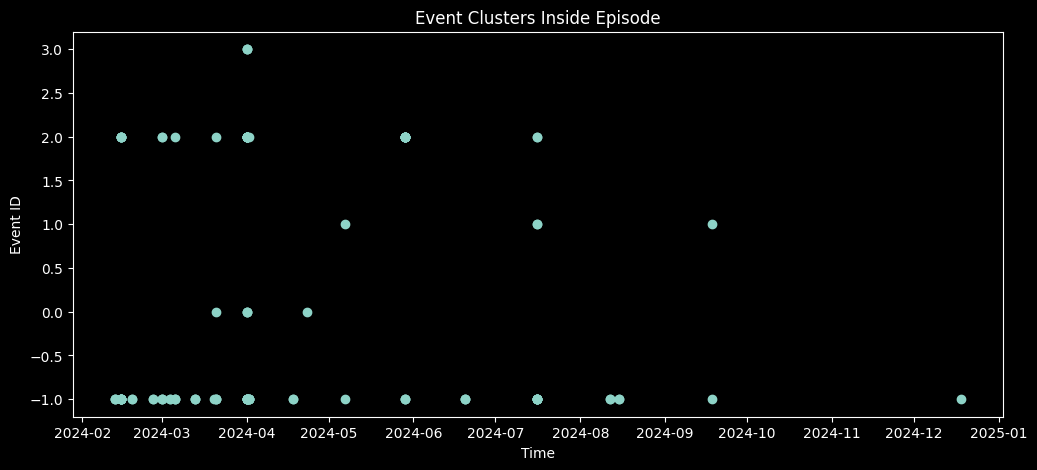

In [220]:
plt.figure(figsize=(12,5))

plt.scatter(
    episode_df["published_date"],
    episode_df["event_id"]
)

plt.xlabel("Time")
plt.ylabel("Event ID")
plt.title("Event Clusters Inside Episode")

plt.show()